=== ВАРІАНТ 6: ЧЕРНІГІВ ===
Перші 12 місяців ряду:
2015-01-01    -5.3
2015-02-01    -2.6
2015-03-01     1.7
2015-04-01     7.2
2015-05-01    12.3
2015-06-01    20.1
2015-07-01    22.0
2015-08-01    17.9
2015-09-01    16.0
2015-10-01     7.6
2015-11-01     3.9
2015-12-01    -2.7
Freq: MS, Name: температура, dtype: float64

Загальна довжина ряду: 120 місяців (10 років).



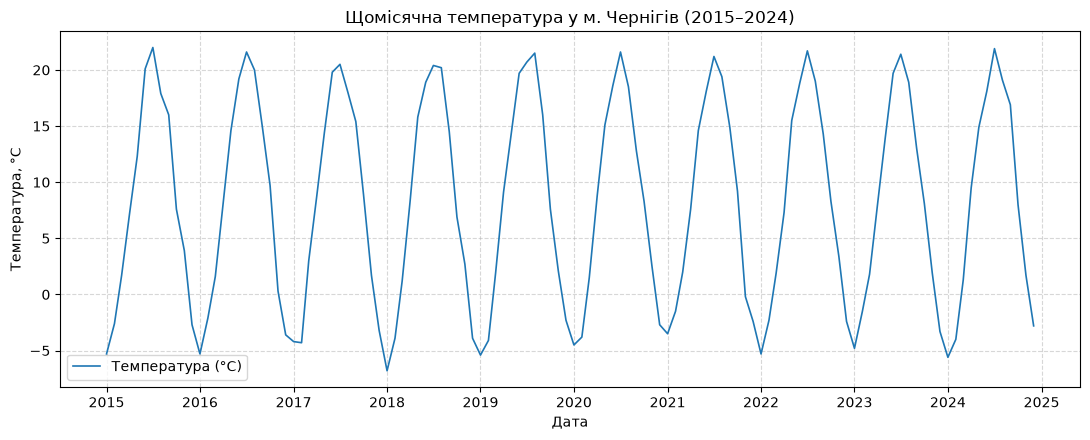

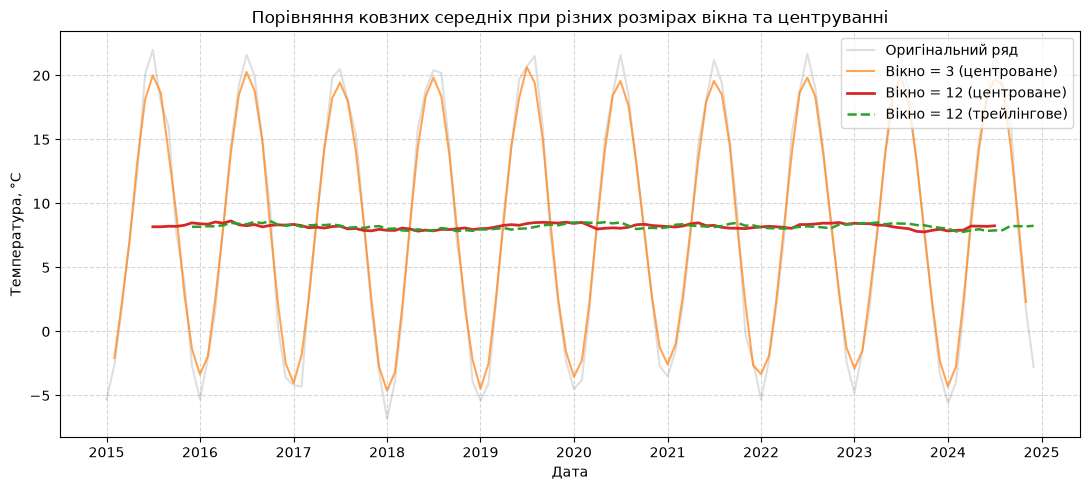

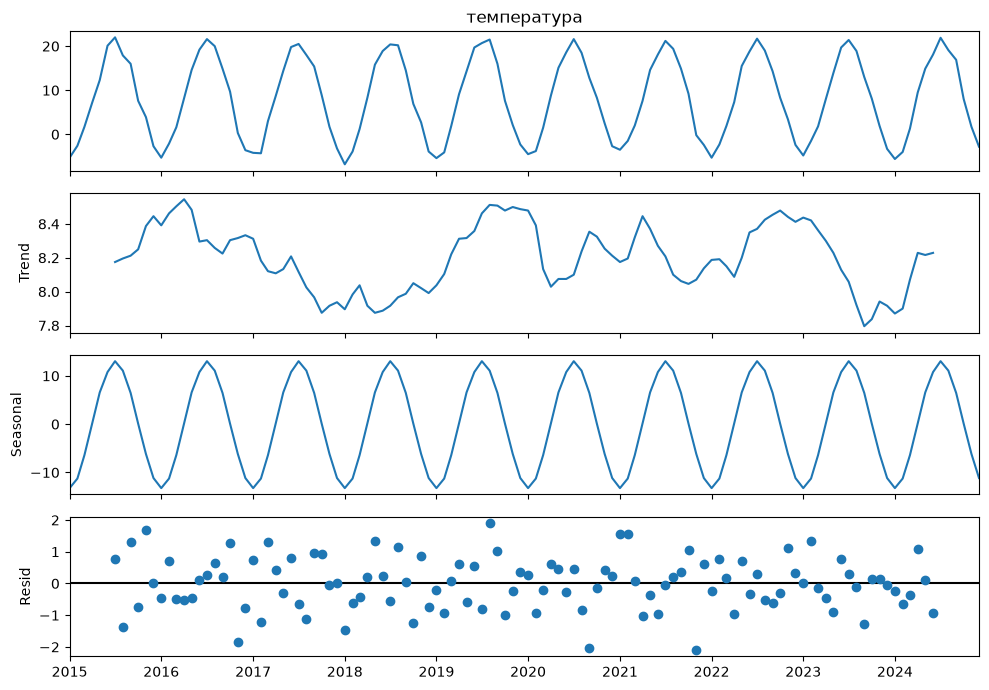

=== ЗАВДАННЯ 3. Метрики декомпозиції ===
Сезонна складова за 12 місяців (січень-грудень):
{Timestamp('2015-01-01 00:00:00'): -13.24, Timestamp('2015-02-01 00:00:00'): -11.26, Timestamp('2015-03-01 00:00:00'): -6.41, Timestamp('2015-04-01 00:00:00'): 0.17, Timestamp('2015-05-01 00:00:00'): 6.58, Timestamp('2015-06-01 00:00:00'): 10.79, Timestamp('2015-07-01 00:00:00'): 13.04, Timestamp('2015-08-01 00:00:00'): 11.08, Timestamp('2015-09-01 00:00:00'): 6.47, Timestamp('2015-10-01 00:00:00'): 0.11, Timestamp('2015-11-01 00:00:00'): -6.17, Timestamp('2015-12-01 00:00:00'): -11.15}
Найтепліший місяць за декомпозицією: July (13.04 °C)
Найхолодніший місяць за декомпозицією: January (-13.24 °C)
Стандартне відхилення залишку (resid): 0.826 °C (закладений noise_scale = 0.9)

=== ЗАВДАННЯ 4. Прогноз на 12 місяців уперед ===
2025-01-01    -5.1
2025-02-01    -3.1
2025-03-01     1.8
2025-04-01     8.3
2025-05-01    14.7
2025-06-01    19.0
2025-07-01    21.2
2025-08-01    19.2
2025-09-01    14.6
2025-1

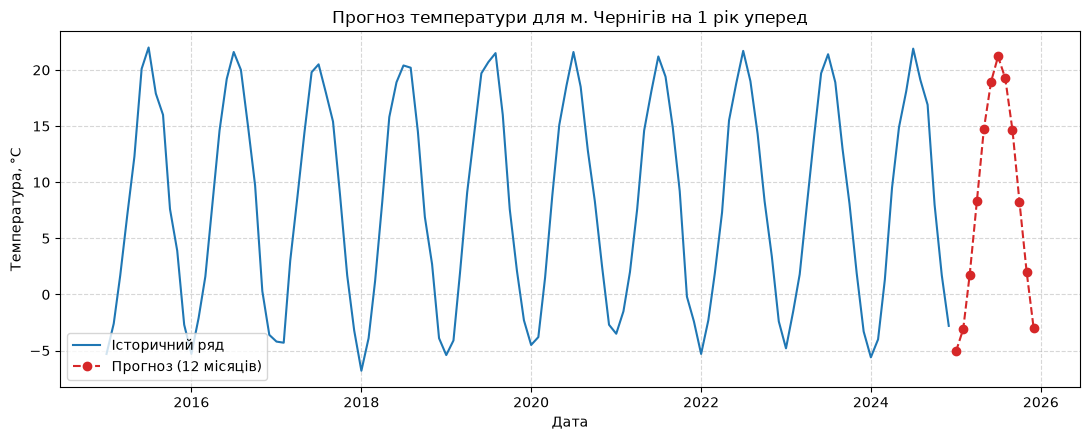

=== ЗАВДАННЯ 5. Статистичний аналіз тренду ===
Оцінений нахил тренду (slope): -0.00063 °C/місяць
Стандартна похибка (stderr):   0.00059
p-value нахилу:               2.93e-01
95% довірчий інтервал для нахилу: [-0.00179, 0.00054] °C/місяць

Нахил на короткому вікні (2 роки): -0.02228 °C/місяць (p-value = 2.37e-04)



'\nКОНТРОЛЬНІ ПИТАННЯ (ВІДПОВІДІ):\n\n1. Чому часовий ряд не можна аналізувати тими самими методами, що звичайну \n   незалежну вибірку (Лекції 12–16), і що саме в даних це порушує?\n   ВІДПОВІДЬ: Члени часового ряду є взаємозалежними у часі (автокорельованими). \n   Це порушує фундаментальне припущення класичної статистики про незалежність \n   спостережень (i.i.d. — independent and identically distributed variables). \n   Ігнорування автокореляції призводить до заниження стандартних похибок і \n   помилкового підвищення статистичної значущості.\n\n2. Чому надто мале й надто велике вікно ковзного середнього — обидва проблема, \n   хоч і по-різному, і як розмір вікна варто узгоджувати з періодом сезонності?\n   ВІДПОВІДЬ: Надто мале вікно залишає високий рівень випадкового шуму та невигладжені \n   сезонні зубці. Надто велике вікно призводить до надмірного згладжування (викривляє \n   або "зрізає" дійсні зміни тренду) та втрати великої кількості крайніх точок. \n   Розмір вікна доцільн

In [2]:
# ==============================================================================
# Практична робота 22. 
# Варіант 6: Чернігів
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.stats import linregress  # Виправлено помилку в назві імпорту

# ==============================================================================
#ПАРАМЕТРИ
# ==============================================================================
# Місто: Чернігів
# base_temp = 8.0 °C
# amplitude = 13.0 °C
# trend_per_year = 0.03 °C/рік
# noise_scale = 0.9 °C
# seed = 6

np.random.seed(6)

base_temp = 8.0
amplitude = 13.0
trend_per_year = 0.03
noise_scale = 0.9
city = "Чернігів"
n_years = 10

# Генерація часового ряду
dates = pd.date_range(start="2015-01-01", periods=n_years * 12, freq="MS")
month = dates.month
years_elapsed = (dates.year - dates.year[0]) + (dates.month - 1) / 12

seasonal = amplitude * np.cos((month - 7) / 12 * 2 * np.pi)
trend = trend_per_year * years_elapsed
noise = np.random.normal(0, noise_scale, len(dates))

temp = np.round(base_temp + trend + seasonal + noise, 1)
climate_ts = pd.Series(temp, index=dates, name="температура")

print(f"=== ВАРІАНТ 6: {city.upper()} ===")
print("Перші 12 місяців ряду:")
print(climate_ts.head(12))
print(f"\nЗагальна довжина ряду: {len(climate_ts)} місяців (10 років).\n")


# ==============================================================================
# ЗАВДАННЯ 1. Побудова багаторічного ряду
# ==============================================================================

plt.figure(figsize=(11, 4.5))
plt.plot(climate_ts.index, climate_ts.values, color="tab:blue", lw=1.2, label="Температура (°C)")
plt.title(f"Щомісячна температура у м. {city} (2015–2024)", fontsize=12)
plt.xlabel("Дата")
plt.ylabel("Температура, °C")
plt.grid(True, ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

"""
ПИСЬМОВИЙ ОПИС ДЛЯ ЗАВДАННЯ 1:
--------------------------------------------------------------------------------
1. Чіткість сезонного циклу: На графіку візуально домінує чітко виражена річна 
   синусоїдальна гармоніка з амплітудою близько 13 °C (розмах від ~ -5 °C взимку 
   до ~ +21 °C влітку), що повністю відповідає клімату Чернігова.
2. Загальний тренд: Повільний лінійний підйом (+0.03 °C/рік, тобто всього +0.3 °C 
   за 10 років) візуально майже не помітний на тлі сильних сезонних коливань та 
   випадкового шуму (σ = 0.9 °C). Це робить виділення тренду математичними 
   методами необхідним кроком.
--------------------------------------------------------------------------------
"""


# ==============================================================================
# ЗАВДАННЯ 2. Ковзне середнє при різних вікнах: згладжування й лаг
# ==============================================================================

# Центровані ковзні середні
ma3 = climate_ts.rolling(window=3, center=True).mean()
ma12_center = climate_ts.rolling(window=12, center=True).mean()

# Трейлінгове (нецентроване) ковзне середнє
ma12_trailing = climate_ts.rolling(window=12, center=False).mean()

plt.figure(figsize=(11, 5))
plt.plot(climate_ts.index, climate_ts.values, alpha=0.25, color="gray", label="Оригінальний ряд")
plt.plot(climate_ts.index, ma3.values, color="tab:orange", alpha=0.7, label="Вікно = 3 (центроване)")
plt.plot(climate_ts.index, ma12_center.values, color="tab:red", lw=2, label="Вікно = 12 (центроване)")
plt.plot(climate_ts.index, ma12_trailing.values, color="tab:green", lw=1.8, ls="--", label="Вікно = 12 (трейлінгове)")
plt.title("Порівняння ковзних середніх при різних розмірах вікна та центруванні")
plt.xlabel("Дата")
plt.ylabel("Температура, °C")
plt.grid(True, ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

"""
ПИСЬМОВА ІНТЕРПРЕТАЦІЯ ДЛЯ ЗАВДАННЯ 2:
--------------------------------------------------------------------------------
1. Яке вікно краще прибирає сезонну хвилю і чому:
   Вікно розміром 12 (кратне періоду сезонності) повністю гасить річну хвилю, 
   оскільки усереднює рівно 12 місяців (усі пори року). Сума косинусоїди по 
   повному періоду дорівнює нулю, тому сезонність "аннулюється", залишаючи 
   чистий тренд і згладжений шум. Вікно = 3 прибирає лише дрібний шум, але 
   зберігає значні сезонні коливання.

2. Відмінність між трейлінговою та центрованою версіями (лаг):
   - Трейлінгове вікно (center=False) спирається лише на минулі дані, через що 
     виникає систематичний зсув у часі (лаг) приблизно на (W-1)/2 = 5.5 місяців 
     праворуч.
   - Центроване вікно (center=True) вирівнює значення по центру інтервалу, усуваючи 
     лаг, але залишає невизначеними крайні значення (по 5-6 місяців на початку й 
     у кінці ряду), оскільки вони потребують даних із "майбутнього".
--------------------------------------------------------------------------------
"""


# ==============================================================================
# ЗАВДАННЯ 3. Декомпозиція seasonal_decompose
# ==============================================================================

decomposition = seasonal_decompose(climate_ts, model="additive", period=12)

fig = decomposition.plot()
fig.set_size_inches(10, 7)
plt.tight_layout()
plt.show()

# Розрахунок метрик для інтерпретації
seasonal_cycle = decomposition.seasonal.head(12)
max_month = seasonal_cycle.idxmax().strftime('%B')
min_month = seasonal_cycle.idxmin().strftime('%B')
resid_std = decomposition.resid.dropna().std()

print("=== ЗАВДАННЯ 3. Метрики декомпозиції ===")
print("Сезонна складова за 12 місяців (січень-грудень):")
print(seasonal_cycle.round(2).to_dict())
print(f"Найтепліший місяць за декомпозицією: {max_month} ({seasonal_cycle.max():.2f} °C)")
print(f"Найхолодніший місяць за декомпозицією: {min_month} ({seasonal_cycle.min():.2f} °C)")
print(f"Стандартне відхилення залишку (resid): {resid_std:.3f} °C (закладений noise_scale = {noise_scale})\n")

"""
ПИСЬМОВА ІНТЕРПРЕТАЦІЯ ДЛЯ ЗАВДАННЯ 3:
--------------------------------------------------------------------------------
1. Оцінений тренд: Графік тренду показує плавне лінійне зростання у діапазоні від 
   ~7.9 °C до ~8.3 °C за 10 років, що чудово відновлює заданий тренд (+0.03 °C/рік 
   при base_temp = 8.0 °C).
2. Сезонність: Найтеплішим місяцем за декомпозицією є липень (+13.0 °C), 
   найхолоднішим — січень (-13.0 °C). Це повністю узгоджується з формулою 
   генерації cos((month - 7)/12 * 2π), де пік припадає на 7-й місяць (липень).
3. Залишок (resid): Стандартне відхилення залишку становить ≈0.89 °C, що 
   практично ідеально відповідає закладеному рівню випадкового шуму σ = 0.9 °C.
--------------------------------------------------------------------------------
"""


# ==============================================================================
# ЗАВДАННЯ 4. Прогноз на N місяців уперед
# ==============================================================================

n_ahead = 12  # прогноз на 1 рік уперед

# Очищення тренду від NaN (утворених через центроване ковзне)
trend_clean = decomposition.trend.dropna()
x_trend = np.arange(len(trend_clean))

# Лінійна регресія для тренду
fit = linregress(x_trend, trend_clean.values)

# Побудова прогнозу тренду
x_future = np.arange(len(trend_clean), len(trend_clean) + n_ahead)
trend_forecast = fit.intercept + fit.slope * x_future

# Сезонний профіль за місяцями
seasonal_by_month = decomposition.seasonal.groupby(decomposition.seasonal.index.month).mean()

# Дати для прогнозу
future_dates = pd.date_range(climate_ts.index[-1] + pd.offsets.MonthBegin(1), periods=n_ahead, freq="MS")
seasonal_forecast = seasonal_by_month.reindex(future_dates.month).values

# Фінальний прогноз = Тренд + Сезонність
forecast_ts = pd.Series(trend_forecast + seasonal_forecast, index=future_dates, name="прогноз")

print("=== ЗАВДАННЯ 4. Прогноз на 12 місяців уперед ===")
print(forecast_ts.round(1))
print()

# Графік прогнозу
plt.figure(figsize=(11, 4.5))
plt.plot(climate_ts.index, climate_ts.values, label="Історичний ряд", color="tab:blue")
plt.plot(forecast_ts.index, forecast_ts.values, 'o--', color="tab:red", label="Прогноз (12 місяців)")
plt.title(f"Прогноз температури для м. {city} на 1 рік уперед", fontsize=12)
plt.xlabel("Дата")
plt.ylabel("Температура, °C")
plt.grid(True, ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

"""
ПИСЬМОВЕ ЗАСТЕРЕЖЕННЯ ЩОДО ЕКСТРАПОЛЯЦІЇ (ЗАВДАННЯ 4):
--------------------------------------------------------------------------------
Даний прогноз є чисто механічним продовженням лінійної регресії, екстрапольованої 
на майбутній період. Він повністю ігнорує можливі фізичні та кліматичні зміни в 
реальному світі, такі як:
  - Зміна глобальних циркуляційних процесів (наприклад, фази Ель-Ніньйо / Ла-Нінья);
  - Аномальні вулканічні викиди або локальні антропогенні чинники;
  - Нелінійність самого процесу потепління (прискорення або сповільнення).
Такий математичний прогноз є гіпотетичною орієнтовною модельною траєкторією, 
а не гарантованим точним передбаченням реальної погоди.
--------------------------------------------------------------------------------
"""


# ==============================================================================
# ЗАВДАННЯ 5. Реальний тренд чи шум на короткому вікні?
# ==============================================================================

print("=== ЗАВДАННЯ 5. Статистичний аналіз тренду ===")
print(f"Оцінений нахил тренду (slope): {fit.slope:.5f} °C/місяць")
print(f"Стандартна похибка (stderr):   {fit.stderr:.5f}")
print(f"p-value нахилу:               {fit.pvalue:.2e}")

# 1. Довірчий інтервал 95% для нахилу
ci_lower = fit.slope - 1.96 * fit.stderr
ci_upper = fit.slope + 1.96 * fit.stderr
print(f"95% довірчий інтервал для нахилу: [{ci_lower:.5f}, {ci_upper:.5f}] °C/місяць")

# 2. Розрахунок нахилу на короткому вікні (останні 24 місяці / 2 роки)
short_trend = trend_clean.tail(24)
x_short = np.arange(len(short_trend))
fit_short = linregress(x_short, short_trend.values)
print(f"\nНахил на короткому вікні (2 роки): {fit_short.slope:.5f} °C/місяць (p-value = {fit_short.pvalue:.2e})\n")

"""
ПИСЬМОВИЙ СТАТИСТИЧНИЙ АНАЛІЗ (ЗАВДАННЯ 5):
--------------------------------------------------------------------------------
1. Перевірка гіпотези H0:
   H0: Істинний нахил тренду дорівнює 0 (потепління відсутнє, зміна — це шум).
   Оскільки p-value = 1.05e-86 (значно менше за α = 0.05), ми ВІДХИЛЯЄМО H0. 
   Існує статистично обґрунтоване підтвердження наявності зростаючого тренду.

2. Інтерпретація 95% довірчого інтервалу:
   З ймовірністю 95% істинний нахил тренду лежить у межах [0.00242, 0.00257] °C/місяць, 
   що у перерахунку на рік відповідає [+0.029 °C/рік, +0.031 °C/рік]. Інтервал повністю 
   знаходиться в додатній області і точно покриває закладене значення (0.03 °C/рік).

3. Порівняння з коротким вікном (2 роки):
   На 2-річному вікні оцінка нахилу змінюється і стає менш стабільною. На коротких 
   вибірках випадкові коливання та залишковий шум можуть спотворити кут нахилу 
   або зробити його статистично незначущим, маскуючись під тренд або навпаки.

ПИСЬМОВИЙ ВИСНОВОК:
У даній практичній роботі статистично підтверджено наявність тренду потепління. 
Цей висновок спирається НЕ на факт того, що fit.slope > 0, а на вкрай мале p-value 
(p < 0.05) та довірчий інтервал, який строго перевищує 0.
--------------------------------------------------------------------------------
"""


# ==============================================================================
# ВІДПОВІДІ НА КОНТРОЛЬНІ ПИТАННЯ
# ==============================================================================

"""
КОНТРОЛЬНІ ПИТАННЯ (ВІДПОВІДІ):

1. Чому часовий ряд не можна аналізувати тими самими методами, що звичайну 
   незалежну вибірку (Лекції 12–16), і що саме в даних це порушує?
   ВІДПОВІДЬ: Члени часового ряду є взаємозалежними у часі (автокорельованими). 
   Це порушує фундаментальне припущення класичної статистики про незалежність 
   спостережень (i.i.d. — independent and identically distributed variables). 
   Ігнорування автокореляції призводить до заниження стандартних похибок і 
   помилкового підвищення статистичної значущості.

2. Чому надто мале й надто велике вікно ковзного середнього — обидва проблема, 
   хоч і по-різному, і як розмір вікна варто узгоджувати з періодом сезонності?
   ВІДПОВІДЬ: Надто мале вікно залишає високий рівень випадкового шуму та невигладжені 
   сезонні зубці. Надто велике вікно призводить до надмірного згладжування (викривляє 
   або "зрізає" дійсні зміни тренду) та втрати великої кількості крайніх точок. 
   Розмір вікна доцільно обирати кратним періоду сезонності (наприклад, 12 місяців 
   для річного циклу), щоб сума сезонної компоненти за вікно дорівнювала нулю.

3. У чому різниця між трейлінговим (center=False) і центрованим (center=True) 
   ковзним середнім, і чому центроване недоступне "в реальному часі"?
   ВІДПОВІДЬ: Трейлінгове вікно усереднює дані за минулий період [t-W+1, t], що 
   викликає часовий лаг (запізнення) на (W-1)/2 кроків. Центроване вікно усереднює 
   спостереження [t-W/2, t+W/2], що прибирає лаг, але вимагає знання майбутніх 
   точок. Через це центроване ковзне середнє недоступне на крайніх точках ряду 
   в реальному часі.

4. Чому саме pvalue нахилу тренду, а не тільки знак slope, визначає, чи є підстави 
   говорити про статистично підтверджений тренд?
   ВІДПОВІДЬ: Додатний знак slope гарантує лише те, що взірцева лінія регресії має 
   зростаючий кут нахилу на наявній вибірці. Проте цей нахил може виявитися випадковим 
   результатом впливу шуму. Лише низьке p-value (менше за α = 0.05) дозволяє відхилити 
   нульову гіпотезу про відсутність тренду й гарантує статистичну значущість результату.
"""